In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sales=pd.read_csv(r'C:\Users\ashwi\OneDrive\Documents\Documents\Retail_Sales_Capstone\data\raw data\sales_data.csv')
customers=pd.read_csv(r'C:\Users\ashwi\OneDrive\Documents\Documents\Retail_Sales_Capstone\data\raw data\customers.csv')
products=pd.read_csv(r'C:\Users\ashwi\OneDrive\Documents\Documents\Retail_Sales_Capstone\data\raw data\products.csv')
returns=pd.read_csv(r'C:\Users\ashwi\OneDrive\Documents\Documents\Retail_Sales_Capstone\data\raw data\returns.csv')
stores=pd.read_csv(r'C:\Users\ashwi\OneDrive\Documents\Documents\Retail_Sales_Capstone\data\raw data\stores.csv')

In [4]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
sales.head()

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
0,O00000,2024-01-31,C0125,P1086,NaN,Online,2,80.63,0.05,153.20
1,O00001,2024-09-29,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.00
2,O00002,2023-08-29,C0653,P0659,NaN,Online,2,218.60,0.10,393.48
3,O00003,2024-05-13,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82
4,O00004,2024-07-22,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94


In [5]:
sales.tail()

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
3055,O02044,2024-09-26,C0580,P0886,S024,In-Store,2,82.92,0.00,165.84
3056,O02352,2023-11-16,C0632,P0091,S034,In-Store,1,27.29,0.10,24.56
3057,O02014,2023-06-25,C0127,P0296,NaN,Online,3,34.89,0.00,104.67
3058,O01371,2025-02-12,C0741,P1056,NaN,Online,1,57.51,0.05,54.63
3059,O00797,2025-03-27,C0479,P0659,NaN,Online,10,218.60,0.10,1967.40


In [6]:
#Describe:numerical stats
sales.describe()

,quantity,unit_price,discount_pct,total_amount
count,3060.000000,3060.000000,3060.000000,3060.000000
mean,1.816340,160.494961,0.088056,272.423582
std,1.749869,91.106112,0.074714,411.177912
min,1.000000,6.770000,0.000000,6.970000
25%,1.000000,83.700000,0.050000,107.467500
50%,2.000000,161.170000,0.050000,196.580000
75%,2.000000,229.100000,0.200000,337.460000
max,30.000000,382.320000,0.200000,8855.800000


In [7]:
#Info:datatypes & nulls
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       3060 non-null   object 
 1   order_date     3060 non-null   object 
 2   customer_id    3060 non-null   object 
 3   product_id     3060 non-null   object 
 4   store_id       2068 non-null   object 
 5   sales_channel  3060 non-null   object 
 6   quantity       3060 non-null   int64  
 7   unit_price     3060 non-null   float64
 8   discount_pct   3060 non-null   float64
 9   total_amount   3060 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 239.2+ KB


In [8]:
sales.columns

Index(['order_id', 'order_date', 'customer_id', 'product_id', 'store_id',
       'sales_channel', 'quantity', 'unit_price', 'discount_pct',
       'total_amount'],
      dtype='object')

In [9]:
#CLEANING SALES DATA
#Standardize column names
sales.columns = sales.columns.str.lower().str.replace(' ', '_')

In [10]:
#removing duplicates
sales.drop_duplicates(inplace=True)

In [11]:
#datatypes
sales.dtypes

order_id          object
order_date        object
customer_id       object
product_id        object
store_id          object
sales_channel     object
quantity           int64
unit_price       float64
discount_pct     float64
total_amount     float64
dtype: object

In [12]:
sales.isnull().sum()

order_id           0
order_date         0
customer_id        0
product_id         0
store_id         968
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64

In [13]:
#replacing null values with unknown
sales['store_id']=sales['store_id'].fillna('-')

In [14]:
sales.isnull().sum()

order_id         0
order_date       0
customer_id      0
product_id       0
store_id         0
sales_channel    0
quantity         0
unit_price       0
discount_pct     0
total_amount     0
dtype: int64

In [15]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
customers.head()

,customer_id,first_name,last_name,gender,age,signup_date,region
0,C0000,Patrick,Morgan,Male,18.0,2024-07-11,South
1,C0001,Eric,Lee,Other,36.0,2020-09-20,East
2,C0002,Thomas,Pena,Female,NaN,2021-03-07,East
3,C0003,Dalton,Duran,Male,24.0,2021-08-29,South
4,C0004,Travis,Mcclain,Male,50.0,2023-03-29,South


In [16]:
customers.tail()

,customer_id,first_name,last_name,gender,age,signup_date,region
811,C0476,John,Le,Female,29.0,2022-11-23,West
812,C0059,Alison,Berger,Male,56.0,2020-11-16,West
813,C0600,Timothy,Cunningham,Male,39.0,2021-04-24,South
814,C0480,Matthew,Moore,Female,27.0,2020-05-23,South
815,C0515,Elizabeth,Alvarez,Other,46.0,2023-07-22,East


In [17]:
#Info:datatypes & nulls
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  816 non-null    object 
 1   first_name   816 non-null    object 
 2   last_name    816 non-null    object 
 3   gender       816 non-null    object 
 4   age          776 non-null    float64
 5   signup_date  816 non-null    object 
 6   region       816 non-null    object 
dtypes: float64(1), object(6)
memory usage: 44.8+ KB


In [18]:
#Describe:numerical stats
customers.describe()

,age
count,776.000000
mean,44.074742
std,15.316349
min,18.000000
25%,31.000000
50%,44.000000
75%,58.000000
max,70.000000


In [19]:
customers.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age',
       'signup_date', 'region'],
      dtype='object')

In [20]:
#Standardize column names
customers.columns = customers.columns.str.lower().str.replace(' ', '_')

In [21]:
#removing duplicates
customers.drop_duplicates(inplace=True)

In [22]:
#datatypes
customers.dtypes

customer_id     object
first_name      object
last_name       object
gender          object
age            float64
signup_date     object
region          object
dtype: object

In [23]:
customers['age'] = pd.to_numeric(customers['age'], errors='coerce').astype('Int64')


In [24]:
customers.isnull().sum()

customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64

In [25]:
#handling missing values
customers['age'] = customers['age'].fillna(customers['age'].median())

In [26]:
customers.isnull().sum()

customer_id    0
first_name     0
last_name      0
gender         0
age            0
signup_date    0
region         0
dtype: int64

In [27]:
products.head()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35


In [28]:
products.tail()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
1219,P0998,BrandB Stuff,Personal Care,BrandD,13.87,19.62,29.31
1220,P0684,BrandA Hear,Home & Kitchen,BrandC,161.31,222.84,27.61
1221,P0498,BrandD South,Personal Care,BrandD,19.73,35.81,44.90
1222,P1016,BrandA Watch,Electronics,BrandC,186.81,321.00,41.80
1223,P0188,BrandA Strong,Apparel,BrandB,172.73,302.59,42.92


In [29]:
#Info:datatypes & nulls
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1224 non-null   object 
 1   product_name  1224 non-null   object 
 2   category      1224 non-null   object 
 3   brand         1164 non-null   object 
 4   cost_price    1224 non-null   float64
 5   unit_price    1224 non-null   float64
 6   margin_pct    1224 non-null   float64
dtypes: float64(3), object(4)
memory usage: 67.1+ KB


In [30]:
#Describe:numerical stats
products.describe()

,cost_price,unit_price,margin_pct
count,1224.000000,1224.000000,1224.000000
mean,103.030016,159.559428,33.869158
std,55.981671,90.679397,11.267576
min,5.290000,6.770000,9.120000
25%,54.697500,83.887500,25.397500
50%,104.490000,157.590000,36.260000
75%,151.342500,226.220000,43.135000
max,199.470000,382.320000,49.990000


In [31]:
products.columns

Index(['product_id', 'product_name', 'category', 'brand', 'cost_price',
       'unit_price', 'margin_pct'],
      dtype='object')

In [32]:
#Standardize column names
products.columns = products.columns.str.lower().str.replace(' ', '_')

In [33]:
#Remove duplicate rows
products.drop_duplicates(inplace=True)

In [34]:
#datatypes
products.dtypes

product_id       object
product_name     object
category         object
brand            object
cost_price      float64
unit_price      float64
margin_pct      float64
dtype: object

In [35]:
products.isnull().sum()

product_id       0
product_name     0
category         0
brand           60
cost_price       0
unit_price       0
margin_pct       0
dtype: int64

In [36]:
products['brand']=products['brand'].fillna('unknown')

In [37]:
products.isnull().sum()

product_id      0
product_name    0
category        0
brand           0
cost_price      0
unit_price      0
margin_pct      0
dtype: int64

In [38]:
returns.head()

,return_id,order_id,return_date,return_reason
0,R0000,O02237,2024-03-05,Defective
1,R0001,O01700,2025-03-18,Defective
2,R0002,O01451,2025-02-18,Late Delivery
3,R0003,O02759,2023-10-26,Defective
4,R0004,O00415,2024-08-06,No Longer Needed


In [39]:
returns.tail()

,return_id,order_id,return_date,return_reason
199,R0199,O01305,2025-01-26,No Longer Needed
200,R0182,O00585,2024-08-24,Late Delivery
201,R0156,O01596,2024-01-27,No Longer Needed
202,R0194,O00934,2024-09-09,Wrong Item
203,R0035,O02071,2023-08-10,Defective


In [40]:
#Info:datatypes & nulls
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   return_id      204 non-null    object
 1   order_id       204 non-null    object
 2   return_date    204 non-null    object
 3   return_reason  204 non-null    object
dtypes: object(4)
memory usage: 6.5+ KB


In [41]:
#Describe:numerical stats
returns.describe()

,return_id,order_id,return_date,return_reason
count,204,204,204,204
unique,200,193,176,4
top,R0035,O00362,2023-08-10,Defective
freq,2,3,4,64


In [42]:
#Standardize column names
returns.columns = returns.columns.str.lower().str.replace(' ', '_')

In [43]:
#Remove duplicate rows
returns.drop_duplicates(inplace=True)

In [44]:
returns.dtypes

return_id        object
order_id         object
return_date      object
return_reason    object
dtype: object

In [45]:
returns.isnull().sum()

return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64

In [46]:
stores.head()

,store_id,store_name,store_type,region,city,operating_cost
0,S000,Vincent Inc Store,Franchise,West,Chicago,62538.56
1,S001,Wilson Inc Store,Flagship,East,Chicago,26957.43
2,S002,Washington-Trujillo Store,Franchise,North,Los Angeles,66101.63
3,S003,Santana and Sons Store,Franchise,South,Phoenix,71089.40
4,S004,Oconnor-Rhodes Store,Franchise,East,Los Angeles,40965.26


In [47]:
stores.tail()

,store_id,store_name,store_type,region,city,operating_cost
56,S056,"Johnson, Sims and Miles Store",Mall Kiosk,East,Los Angeles,75869.37
57,S057,"Crawford, Spencer and Lopez Store",Franchise,West,Houston,52756.63
58,S058,Hubbard-Thomas Store,Mall Kiosk,East,New York,10215.93
59,S059,"Foster, Gutierrez and Li Store",Franchise,West,Los Angeles,11797.63
60,S017,Robinson PLC Store,Flagship,East,Phoenix,47603.84


In [48]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   store_id        61 non-null     object 
 1   store_name      61 non-null     object 
 2   store_type      61 non-null     object 
 3   region          61 non-null     object 
 4   city            61 non-null     object 
 5   operating_cost  61 non-null     float64
dtypes: float64(1), object(5)
memory usage: 3.0+ KB


In [49]:
#Describe:numerical stats
stores.describe()

,operating_cost
count,61.000000
mean,40329.226721
std,19225.845475
min,10215.930000
25%,22350.490000
50%,39178.960000
75%,52756.630000
max,78806.300000


In [50]:
#Data Cleaning
#standardizing columns
stores.columns = stores.columns.str.lower().str.replace(' ', '_')

In [51]:
#Remove duplicate rows
stores.drop_duplicates(inplace=True)

In [52]:
stores.dtypes

store_id           object
store_name         object
store_type         object
region             object
city               object
operating_cost    float64
dtype: object

In [53]:
stores.isnull().sum()

store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64

In [54]:
#Create Derived Column – Profit
sales= sales.merge(products[["product_id","cost_price"]],on="product_id",how="left")

sales["profit"] = (sales["total_amount"]-(sales["cost_price"] *sales["quantity"]))

In [55]:
sales.columns

Index(['order_id', 'order_date', 'customer_id', 'product_id', 'store_id',
       'sales_channel', 'quantity', 'unit_price', 'discount_pct',
       'total_amount', 'cost_price', 'profit'],
      dtype='object')

In [56]:
#Create Derived Column – Age Group
customers['age_group'] = pd.cut( customers['age'],bins=[0, 18, 25, 35, 50, 100],labels=['15-18', '18-25', '26-35', '36-50', '50+'],right=True)


In [57]:
customers.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age',
       'signup_date', 'region', 'age_group'],
      dtype='object')

In [58]:
customers.dtypes

customer_id      object
first_name       object
last_name        object
gender           object
age               Int64
signup_date      object
region           object
age_group      category
dtype: object

In [59]:
customers.isnull().sum()

customer_id    0
first_name     0
last_name      0
gender         0
age            0
signup_date    0
region         0
age_group      0
dtype: int64

In [60]:
products.columns

Index(['product_id', 'product_name', 'category', 'brand', 'cost_price',
       'unit_price', 'margin_pct'],
      dtype='object')

In [61]:
products.dtypes

product_id       object
product_name     object
category         object
brand            object
cost_price      float64
unit_price      float64
margin_pct      float64
dtype: object

In [62]:
products.isnull().sum()

product_id      0
product_name    0
category        0
brand           0
cost_price      0
unit_price      0
margin_pct      0
dtype: int64

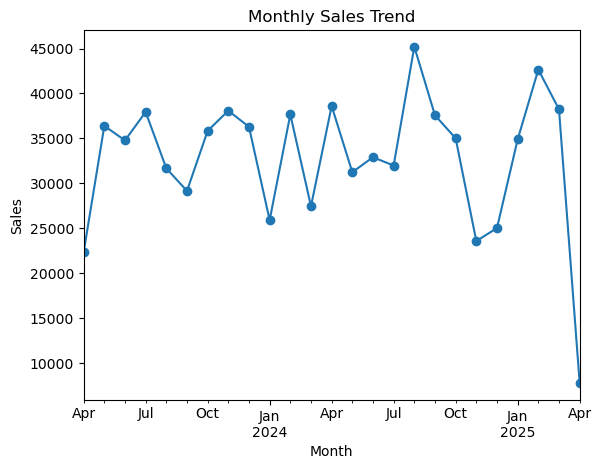

In [63]:
#Sales-EDA
#Monthly Sales Trend
sales['order_date'] = pd.to_datetime(sales['order_date'])
sales['month'] = sales['order_date'].dt.to_period('M')

monthly_sales = sales.groupby('month')['total_amount'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

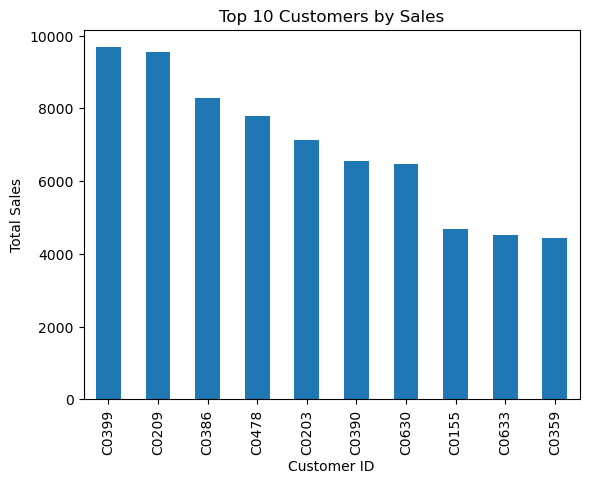

In [ ]:
#Customers-EDA:top customers
top_customers = sales.groupby('customer_id')['total_amount'].sum().sort_values(ascending=False)
top_10_customers = top_customers.head(10)
top_10_customers.plot(kind='bar')
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.show()

In [65]:
sales.to_csv(r"C:\Users\ashwi\Downloads\sales_cleaned.csv", index=False)
customers.to_csv(r"C:\Users\ashwi\Downloads\customers_cleaned.csv", index=False)
products.to_csv(r"C:\Users\ashwi\Downloads\products_cleaned.csv", index=False)
returns.to_csv(r"C:\Users\ashwi\Downloads\returns_cleaned.csv", index=False)
stores.to_csv(r"C:\Users\ashwi\Downloads\stores_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
